<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
import kagglehub

In [3]:
def get_dataloader(image_size, batch_size, device):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  transforms = tt.Compose([
      tt.Resize(image_size),
      tt.ToTensor(),
  ])

  path = kagglehub.dataset_download("tommykamaz/faces-dataset-small")
  faceDataset = ImageFolder(path, transform=transforms)

  dataloader = DataLoader(faceDataset, batch_size=batch_size,
                          shuffle=True, num_workers=4,
                          pin_memory_device=device, pin_memory=True)
  return dataloader

In [62]:
image_size = 128
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
face_loader = get_dataloader(image_size, batch_size, device)


Using Colab cache for faster access to the 'faces-dataset-small' dataset.


## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [63]:
discriminator = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 128, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 256, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 512, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.Conv2d(512, 1024, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(1024),
    nn.ReLU(inplace=True),
    nn.Conv2d(1024, 1, kernel_size=4, padding=0, stride=1),
    nn.Flatten(),
    nn.Sigmoid()
)

In [64]:
latent_size = 128

generator = nn.Sequential(
    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, padding=0, stride=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(512, 256, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(256, 128, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(128, 64, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(64, 32, kernel_size=4, padding=1, stride=2),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(32, 3, kernel_size=4, padding=1, stride=2),
    nn.Tanh()
)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [65]:
import torch.optim as optim

In [66]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}



In [67]:
from tqdm.notebook import tqdm

def fit(model, criterion, epochs, lr, device):

  model['discriminator'] = model['discriminator'].to(device)
  model['generator'] = model['generator'].to(device)

  model['discriminator'].train()
  model['generator'].train()

  optimizer = {
      'discriminator': optim.Adam(params=model['discriminator'].parameters(), lr=lr, betas=(0.5, 0.999)),
      'generator': optim.Adam(params=model['generator'].parameters(), lr=lr, betas=(0.5, 0.999)),
  }

  losses_g = []
  losses_d = []

  real_scores = []
  fake_scores = []

  for epoch in tqdm(range(1, epochs+1), desc='Epochs'):

    losses_g_per_epoch = []
    losses_d_per_epoch = []

    real_score_per_epoch = []
    fake_score_per_epoch = []

    for images, _ in tqdm(face_loader, desc='Batch'):

      # Train discriminator
      images = images.to(device)
      optimizer['discriminator'].zero_grad()

      real_preds = model['discriminator'](images)
      real_targets = torch.ones(images.size(0), 1, device=device)
      real_loss = criterion['discriminator'](real_preds, real_targets)
      cur_real_score = torch.mean(real_loss).item()

      latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
      fake_images = model['generator'](latent)

      fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
      fake_preds = model['discriminator'](fake_images)
      fake_loss = criterion['discriminator'](fake_preds, fake_targets)
      cur_fake_score = torch.mean(fake_loss).item()

      real_score_per_epoch.append(cur_real_score)
      fake_score_per_epoch.append(cur_fake_score)

      loss_d = fake_loss + real_loss
      loss_d.backward()

      optimizer['discriminator'].step()
      losses_d_per_epoch.append(loss_d.item())

      # Train generator
      optimizer['generator'].zero_grad()

      latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
      fake_images = model['generator'](latent)

      preds = model['discriminator'](fake_images)
      targets = torch.ones(batch_size, 1, device=device)
      loss_g = criterion['generator'](preds, targets)

      loss_g.backward()
      optimizer['generator'].step()

      losses_g_per_epoch.append(loss_g.item())

    losses_g.append(np.mean(losses_g_per_epoch))
    losses_d.append(np.mean(losses_d_per_epoch))

    real_scores.append(np.mean(real_score_per_epoch))
    fake_scores.append(np.mean(fake_score_per_epoch))

    print(f"Epoch: {epoch}/{epochs}, loss_g: {losses_g[-1]:.4f}, \
    losses_d: {losses_d[-1]:.4f}, real_score: {real_scores[-1]:.4f}, fake_score: {fake_scores[-1]:.4f}")




  return losses_d, losses_g

In [ ]:
losses_d, losses_g = fit(model, criterion, epochs=40, lr=lr, device=device)

Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Batch:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch: 1/40, loss_g: 9.5768,     losses_d: 0.0390, real_score: 0.0186, fake_score: 0.0204


Batch:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch: 2/40, loss_g: 11.5425,     losses_d: 0.2648, real_score: 0.2380, fake_score: 0.0268


...

Batch:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch: 6/40, loss_g: 5.1964,     losses_d: 0.2291, real_score: 0.1128, fake_score: 0.1163


Batch:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch: 7/40, loss_g: 5.4229,     losses_d: 0.0538, real_score: 0.0299, fake_score: 0.0239


Batch:   0%|          | 0/99 [00:00<?, ?it/s]

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [36]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

In [37]:
fake_images = fake_images.cpu().detach().numpy()

In [38]:
fake_images.shape

(4, 3, 128, 128)

In [41]:
fake_images = fake_images.reshape((4, 128, 128, 3))

In [42]:
fake_images.shape

(4, 128, 128, 3)

In [48]:
def show_images(generated):
  fig, axes = plt.subplots(figsize=(8, 8))
  axes.set_xticks([]); axes.set_yticks([])
  axes.imshow(generated)

TypeError: Invalid shape (4, 128, 128, 3) for image data

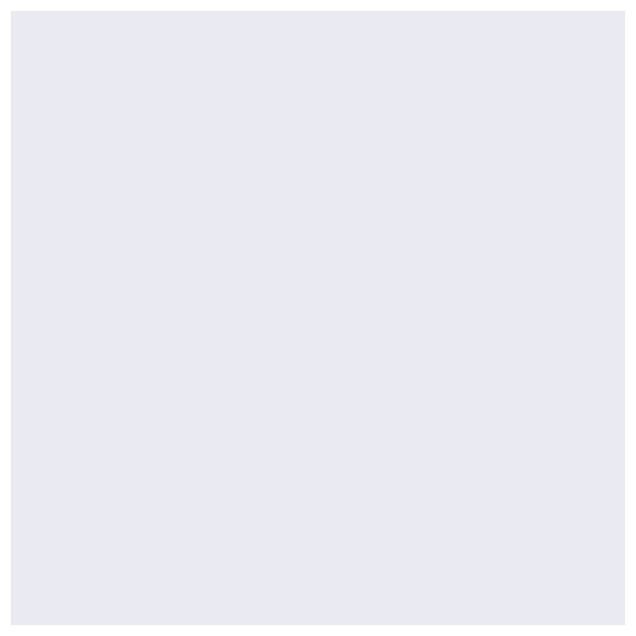

In [49]:
show_images(fake_images)

Как вам качество получившихся изображений?

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

Прокомментируйте получившийся результат: